# Phân loại tin nhắn SMS Spam / Ham bằng Multinomial Naive Bayes

## Bước 1. Bài toán

- **Loại**: phân loại nhị phân trên văn bản. Input: nội dung SMS. Output: `ham` hoặc `spam`.
- **Lớp dương**: `spam`, chỉ ~13% dữ liệu → **mất cân bằng**, accuracy không đáng tin (đoán ham suông đã đúng 87%).
- **FP** (chặn nhầm tin thường) tệ hơn **FN** (lọt spam): mất OTP hay tin người thân thì không khôi phục được, còn spam chỉ cần xoá.
- → Ưu tiên **precision của lớp spam**, dùng **F1** làm chỉ số tổng hợp khi so sánh và tinh chỉnh.

## Nạp thư viện

Cố định `random_state = 42` ở mọi chỗ có yếu tố ngẫu nhiên để kết quả tái lập được.

In [4]:
# B1 — Nạp thư viện và thiết lập chung
import os
import re
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score, roc_curve, roc_auc_score,
)
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.width", 120)

print("Đã nạp xong thư viện.")
print("Phiên bản pandas:", pd.__version__)
import sklearn; print("Phiên bản scikit-learn:", sklearn.__version__)

ModuleNotFoundError: No module named 'matplotlib'

## Bước 2. Nạp dữ liệu

SMS Spam Collection (UCI) — 5.572 tin nhắn tiếng Anh đã gán nhãn.
Nguồn: <https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset>

Ô code tự tải `spam.csv` nếu chưa có; bạn cũng có thể tự tải từ Kaggle đặt cạnh notebook.

- Encoding **`latin-1`**, đọc bằng `utf-8` sẽ lỗi.
- File có 5 cột nhưng 3 cột cuối là rác → chỉ lấy `v1` (nhãn) và `v2` (nội dung).

In [2]:
# B2 — Tải và nạp dữ liệu
DATA_PATH = "spam.csv"
DATA_URL = "https://raw.githubusercontent.com/mohitgupta-1O1/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv"

if not os.path.exists(DATA_PATH):
    print("Chưa thấy spam.csv, đang tải từ nguồn công khai...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print("Tải xong.")
else:
    print(f"Đã có sẵn file '{DATA_PATH}', dùng luôn file này.")

df_raw = pd.read_csv(DATA_PATH, encoding="latin-1")
print("\nCác cột gốc trong file:", list(df_raw.columns))

df = df_raw.iloc[:, :2].copy()
df.columns = ["label", "message"]

print(f"\nTổng số mẫu ban đầu: {len(df):,}")
print("\nPhân bố nhãn (số lượng):")
print(df["label"].value_counts())
print("\nPhân bố nhãn (tỉ lệ %):")
print((df["label"].value_counts(normalize=True) * 100).round(2))

spam_rate = (df["label"] == "spam").mean() * 100
print(f"\n>>> Tỉ lệ spam trong dữ liệu gốc: {spam_rate:.2f}%")

df.head()

Đã có sẵn file 'spam.csv', dùng luôn file này.

Các cột gốc trong file: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Tổng số mẫu ban đầu: 5,572

Phân bố nhãn (số lượng):
label
ham     4825
spam     747
Name: count, dtype: int64

Phân bố nhãn (tỉ lệ %):
label
ham    86.5900
spam   13.4100
Name: proportion, dtype: float64

>>> Tỉ lệ spam trong dữ liệu gốc: 13.41%


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Nhận xét

Spam chỉ ~13% → dữ liệu mất cân bằng. Ba hệ quả: phải `stratify` khi chia tập, không lấy accuracy làm chỉ số
chính, và `GridSearchCV` phải chấm điểm bằng `f1`.

## Bước 3. EDA

Kiểm tra null → loại dòng trùng lặp → so sánh độ dài → vẽ biểu đồ.

In [3]:
# B3.1 — Kiểm tra giá trị thiếu
print("Số giá trị thiếu theo từng cột:")
print(df.isnull().sum())
print("\nSố tin nhắn rỗng (chuỗi chỉ toàn khoảng trắng):",
      (df["message"].astype(str).str.strip() == "").sum())

Số giá trị thiếu theo từng cột:
label      0
message    0
dtype: int64

Số tin nhắn rỗng (chuỗi chỉ toàn khoảng trắng): 0


In [4]:
# B3.2 — Loại bỏ dòng trùng lặp (bản trùng lọt vào cả train lẫn test sẽ thổi phồng kết quả)
n_duplicates = df.duplicated().sum()
print(f"Số dòng trùng lặp hoàn toàn (cả nhãn lẫn nội dung): {n_duplicates:,}")

print("\n5 nội dung bị lặp nhiều nhất:")
print(df[df.duplicated(keep=False)]["message"].value_counts().head(5))

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nSố mẫu: {before:,} -> {len(df):,} (đã bỏ {before - len(df):,} dòng)")
print("\nPhân bố nhãn sau khi lọc trùng:")
print(df["label"].value_counts())
print(f"\n>>> Tỉ lệ spam sau khi lọc trùng: {(df['label'] == 'spam').mean() * 100:.2f}%")

Số dòng trùng lặp hoàn toàn (cả nhãn lẫn nội dung): 403

5 nội dung bị lặp nhiều nhất:
message
Sorry, I'll call later                                                                                                                                                                 30
I cant pick the phone right now. Pls send a message                                                                                                                                    12
Ok...                                                                                                                                                                                  10
Please call our customer service representative on FREEPHONE 0808 145 4742 between 9am-11pm as you have WON a guaranteed å£1000 cash or å£5000 prize!                                   4
Wen ur lovable bcums angry wid u, dnt take it seriously.. Coz being angry is d most childish n true way of showing deep affection, care n luv!.. kettoda manda...

In [5]:
# B3.3 — Thống kê độ dài tin nhắn theo nhãn
df["length"] = df["message"].astype(str).str.len()
df["n_words"] = df["message"].astype(str).str.split().str.len()

length_stats = df.groupby("label")[["length", "n_words"]].agg(["mean", "median", "max"]).round(2)
print("Thống kê độ dài tin nhắn theo nhãn:")
print(length_stats)

print("\nĐộ dài trung bình (ký tự):")
for lb, v in df.groupby("label")["length"].mean().items():
    print(f"  - {lb:>4}: {v:.1f} ký tự")

Thống kê độ dài tin nhắn theo nhãn:
        length               n_words             
          mean   median  max    mean  median  max
label                                            
ham    70.4600  52.0000  910 14.1300 11.0000  171
spam  137.8900 149.0000  224 23.6800 25.0000   35

Độ dài trung bình (ký tự):
  -  ham: 70.5 ký tự
  - spam: 137.9 ký tự


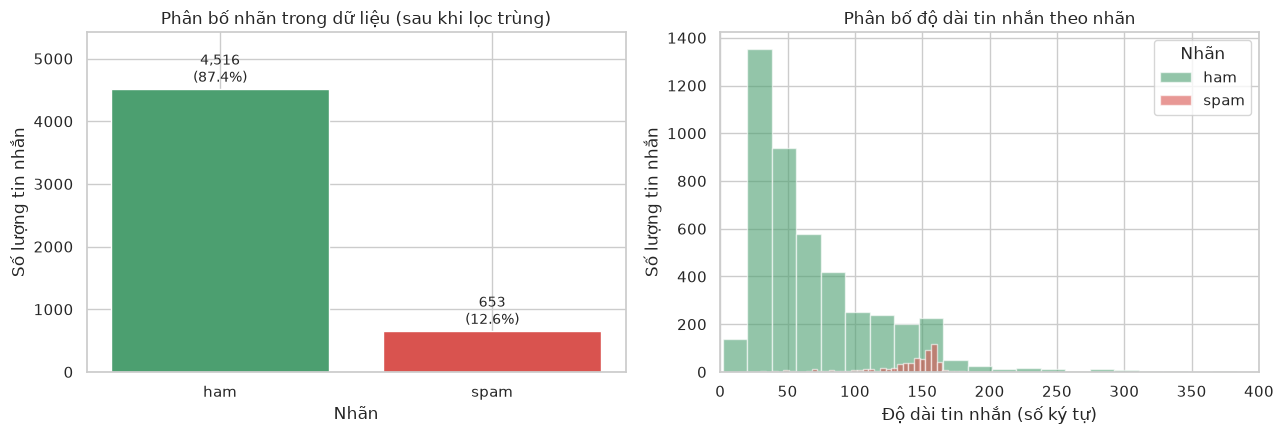

In [6]:
# B3.4 — Biểu đồ: phân bố nhãn và phân bố độ dài
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

counts = df["label"].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=["#4C9F70", "#D9534F"])
axes[0].set_title("Phân bố nhãn trong dữ liệu (sau khi lọc trùng)")
axes[0].set_xlabel("Nhãn")
axes[0].set_ylabel("Số lượng tin nhắn")
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 40, f"{v:,}\n({v/len(df)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=10)
axes[0].set_ylim(0, counts.max() * 1.2)

for lb, color in [("ham", "#4C9F70"), ("spam", "#D9534F")]:
    axes[1].hist(df.loc[df["label"] == lb, "length"], bins=50, alpha=0.6,
                 label=lb, color=color)
axes[1].set_title("Phân bố độ dài tin nhắn theo nhãn")
axes[1].set_xlabel("Độ dài tin nhắn (số ký tự)")
axes[1].set_ylabel("Số lượng tin nhắn")
axes[1].legend(title="Nhãn")
axes[1].set_xlim(0, 400)

plt.tight_layout()
plt.show()

### Bốn góc nhìn bổ sung

Donut (tỉ lệ), boxplot (trung vị và độ phân tán), histogram mật độ (so sánh hình dạng mà không bị lệch vì ham
đông gấp 7 lần), phân bố số từ (kiểm chứng lại bằng đơn vị đo khác).

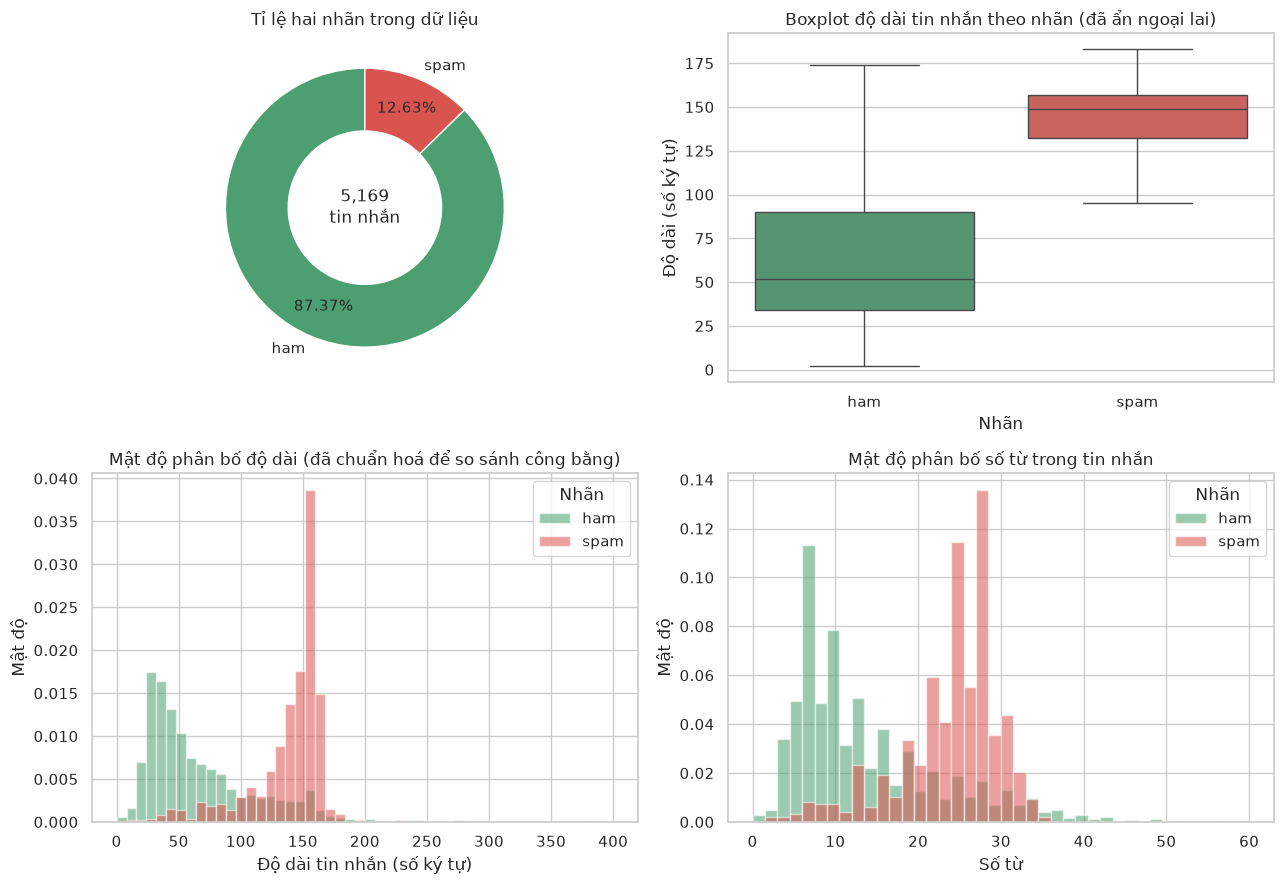

In [7]:
# B3.5 — Biểu đồ: donut, boxplot, mật độ độ dài, số từ
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

counts = df["label"].value_counts()
mau = {"ham": "#4C9F70", "spam": "#D9534F"}

axes[0, 0].pie(counts.values, labels=counts.index, autopct="%1.2f%%", startangle=90,
               colors=[mau[l] for l in counts.index], wedgeprops=dict(width=0.45, edgecolor="white"),
               pctdistance=0.77, textprops={"fontsize": 11})
axes[0, 0].text(0, 0, f"{len(df):,}\ntin nhắn", ha="center", va="center", fontsize=12)
axes[0, 0].set_title("Tỉ lệ hai nhãn trong dữ liệu")

sns.boxplot(data=df, x="label", y="length", hue="label", palette=mau, ax=axes[0, 1],
            showfliers=False, legend=False)
axes[0, 1].set_title("Boxplot độ dài tin nhắn theo nhãn (đã ẩn ngoại lai)")
axes[0, 1].set_xlabel("Nhãn")
axes[0, 1].set_ylabel("Độ dài (số ký tự)")

for lb in ["ham", "spam"]:
    axes[1, 0].hist(df.loc[df["label"] == lb, "length"], bins=50, range=(0, 400),
                    density=True, alpha=0.55, label=lb, color=mau[lb])
axes[1, 0].set_title("Mật độ phân bố độ dài (đã chuẩn hoá để so sánh công bằng)")
axes[1, 0].set_xlabel("Độ dài tin nhắn (số ký tự)")
axes[1, 0].set_ylabel("Mật độ")
axes[1, 0].legend(title="Nhãn")

for lb in ["ham", "spam"]:
    axes[1, 1].hist(df.loc[df["label"] == lb, "n_words"], bins=40, range=(0, 60),
                    density=True, alpha=0.55, label=lb, color=mau[lb])
axes[1, 1].set_title("Mật độ phân bố số từ trong tin nhắn")
axes[1, 1].set_xlabel("Số từ")
axes[1, 1].set_ylabel("Mật độ")
axes[1, 1].legend(title="Nhãn")

plt.tight_layout()
plt.show()

### Từ phổ biến nhất ở mỗi nhãn

Xem trước mô hình sẽ dựa vào những từ nào để phân biệt.

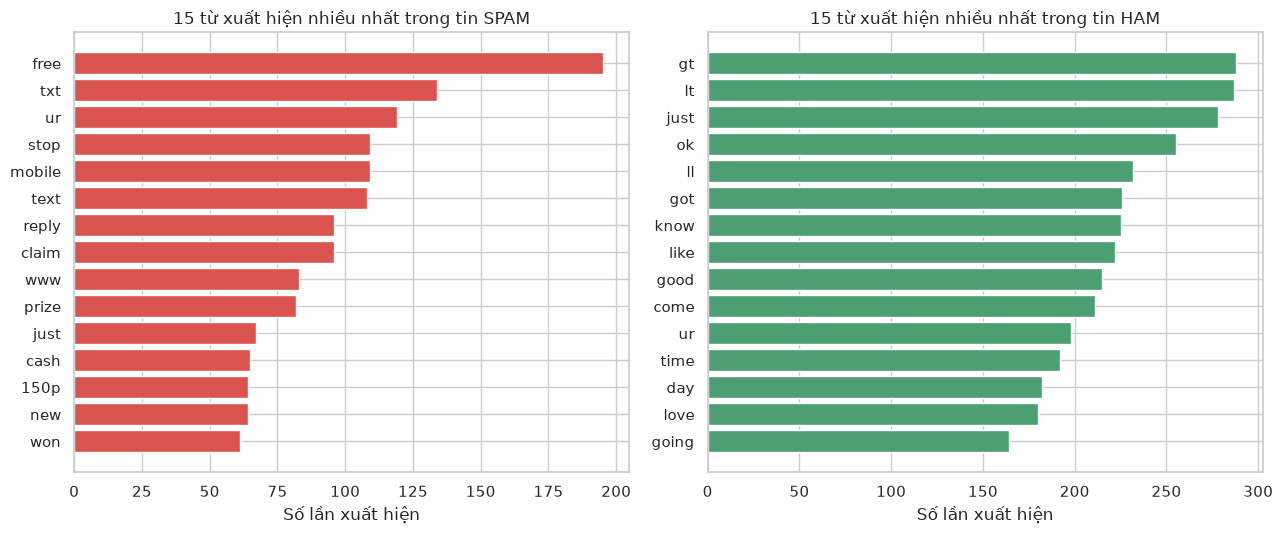

In [8]:
# B3.6 — Biểu đồ: từ xuất hiện nhiều nhất ở mỗi nhãn
def dem_tu_pho_bien(texts, top_n=15):
    """Trả về top_n từ phổ biến nhất. Lọc stop words, nếu không kết quả sẽ toàn 'the', 'to', 'you'."""
    cv = CountVectorizer(stop_words="english")
    X_counts = cv.fit_transform(texts)
    tong = np.asarray(X_counts.sum(axis=0)).ravel()
    tu = np.array(cv.get_feature_names_out())
    idx = np.argsort(tong)[::-1][:top_n]
    return tu[idx], tong[idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, lb, color in [(axes[0], "spam", "#D9534F"), (axes[1], "ham", "#4C9F70")]:
    tu, so_lan = dem_tu_pho_bien(df.loc[df["label"] == lb, "message"])
    ax.barh(range(len(tu)), so_lan[::-1], color=color)
    ax.set_yticks(range(len(tu))); ax.set_yticklabels(tu[::-1])
    ax.set_title(f"15 từ xuất hiện nhiều nhất trong tin {lb.upper()}")
    ax.set_xlabel("Số lần xuất hiện")

plt.tight_layout()
plt.show()

### Word Cloud

Nhìn toàn cảnh ~120 từ mỗi lớp. Cần `pip install wordcloud`; thiếu thư viện thì ô này tự bỏ qua, không ảnh
hưởng các bước sau.

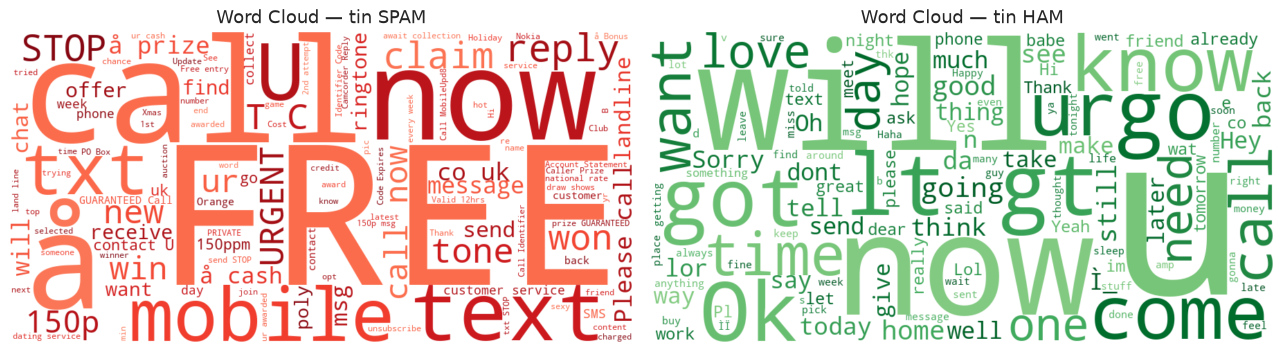

In [9]:
# B3.7 — Word Cloud của hai lớp
try:
    from wordcloud import WordCloud
    from matplotlib.colors import LinearSegmentedColormap

    def cat_colormap(ten, tu=0.45, den=0.95, n=200):
        """Cắt lấy phần đậm của bảng màu, vì phần nhạt gần như không đọc được trên nền trắng."""
        goc = plt.get_cmap(ten)
        return LinearSegmentedColormap.from_list(f"{ten}_dam", goc(np.linspace(tu, den, n)))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, lb, colormap in [(axes[0], "spam", cat_colormap("Reds")),
                             (axes[1], "ham", cat_colormap("Greens"))]:
        van_ban = " ".join(df.loc[df["label"] == lb, "message"].astype(str))
        wc = WordCloud(width=900, height=450, background_color="white",
                       colormap=colormap, max_words=120,
                       random_state=RANDOM_STATE).generate(van_ban)
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(f"Word Cloud — tin {lb.upper()}", fontsize=13)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Chưa cài thư viện 'wordcloud'. Chạy: pip install wordcloud")
    print("Bỏ qua ô này, các bước sau vẫn hoạt động bình thường.")

### Nhận xét Bước 3

- Bỏ **403 dòng trùng lặp**, còn **5.169 mẫu**, spam **12,63%**.
- Spam dài gần gấp đôi ham: **137,9 vs 70,5 ký tự** (trung vị 149 vs 52). Boxplot hai lớp gần như không chồng lấn.
- Spam dồn quanh 120–160 ký tự (sát giới hạn một SMS); ham tản mát từ "Ok" tới 910 ký tự.
- Top từ spam: *free, txt, ur, stop, mobile, claim, prize*. Top từ ham: *just, ok, got, know, like, come*.
  Hai bộ từ vựng gần như không giao nhau → bài toán khả thi với Naive Bayes.
- *gt*, *lt* đứng đầu phía ham chính là `&gt;` / `&lt;` chưa được giải mã trong dữ liệu gốc.

## Bước 4. Tiền xử lý văn bản

`clean_text()` chuyển chữ thường, bỏ URL, bỏ chữ số, bỏ dấu câu, gộp khoảng trắng.

Nhưng xoá số và URL là xoá luôn số tổng đài và đường link — dấu hiệu spam mạnh nhất. Phải đo bằng thực nghiệm.

In [10]:
# B4.1 — Hàm làm sạch văn bản
URL_PATTERN = re.compile(r"http\S+|www\.\S+")

def clean_text(text: str) -> str:
    """Làm sạch tin nhắn. Lưu ý: xoá chữ số và URL là xoá luôn dấu hiệu spam mạnh nhất."""
    text = str(text).lower()
    text = URL_PATTERN.sub(" ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["message_clean"] = df["message"].apply(clean_text)

print("VÍ DỤ TRƯỚC / SAU KHI LÀM SẠCH")
print("=" * 90)
for i in df[df["label"] == "spam"].index[:2].tolist() + df[df["label"] == "ham"].index[:2].tolist():
    print(f"[{df.loc[i, 'label'].upper():>4}] GỐC  : {df.loc[i, 'message'][:110]}")
    print(f"       SẠCH : {df.loc[i, 'message_clean'][:110]}")
    print("-" * 90)

VÍ DỤ TRƯỚC / SAU KHI LÀM SẠCH
[SPAM] GỐC  : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question
       SẠCH : free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry question std txt rate t 
------------------------------------------------------------------------------------------
[SPAM] GỐC  : FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb o
       SẠCH : freemsg hey there darling it s been week s now and no word back i d like some fun you up for it still tb ok xx
------------------------------------------------------------------------------------------
[ HAM] GỐC  : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..
       SẠCH : go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
---------------------------------------------

### Việc làm sạch đang vứt đi cái gì?

Đếm tỉ lệ tin nhắn mỗi lớp có chứa từng tín hiệu mà `clean_text()` sẽ xoá.

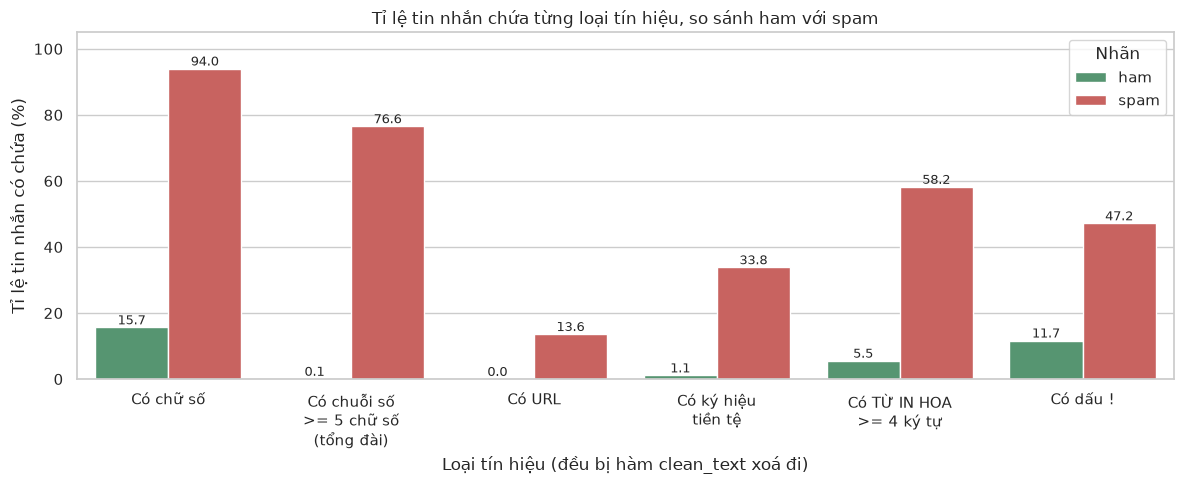

Nhãn                                   ham    spam  Spam gấp ham (lần)
Có TỪ IN HOA >= 4 ký tự             5.5400 58.1900             10.5000
Có URL                              0.0200 13.6300            615.5000
Có chuỗi số >= 5 chữ số (tổng đài)  0.0700 76.5700          1,152.6000
Có chữ số                          15.6600 94.0300              6.0000
Có dấu !                           11.6700 47.1700              4.0000
Có ký hiệu tiền tệ                  1.1100 33.8400             30.6000


In [11]:
# B4.2 — Biểu đồ: những tín hiệu mà việc làm sạch sẽ xoá mất
tin_hieu = {
    "Có chữ số": r"\d",
    "Có chuỗi số\n>= 5 chữ số\n(tổng đài)": r"\d{5,}",
    "Có URL": r"http\S+|www\.\S+",
    "Có ký hiệu\ntiền tệ": r"[£$å£]|\bgbp\b",
    "Có TỪ IN HOA\n>= 4 ký tự": r"\b[A-Z]{4,}\b",
    "Có dấu !": r"!",
}

rows = []
for ten, pattern in tin_hieu.items():
    for lb in ["ham", "spam"]:
        s = df.loc[df["label"] == lb, "message"].astype(str)
        rows.append({"Tín hiệu": ten, "Nhãn": lb, "Tỉ lệ (%)": s.str.contains(pattern, regex=True).mean() * 100})

signal_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=signal_df, x="Tín hiệu", y="Tỉ lệ (%)", hue="Nhãn",
            palette={"ham": "#4C9F70", "spam": "#D9534F"}, ax=ax)
ax.set_title("Tỉ lệ tin nhắn chứa từng loại tín hiệu, so sánh ham với spam")
ax.set_xlabel("Loại tín hiệu (đều bị hàm clean_text xoá đi)")
ax.set_ylabel("Tỉ lệ tin nhắn có chứa (%)")
ax.set_ylim(0, 105)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=9)
plt.tight_layout()
plt.show()

pivot = signal_df.pivot(index="Tín hiệu", columns="Nhãn", values="Tỉ lệ (%)")
pivot.index = [t.replace("\n", " ") for t in pivot.index]
pivot["Spam gấp ham (lần)"] = (pivot["spam"] / pivot["ham"].replace(0, np.nan)).round(1)
print(pivot.round(2).to_string())

### Nhận xét

| Tín hiệu | Ham | Spam | Spam gấp ham |
|---|---|---|---|
| Chuỗi số ≥ 5 chữ số (tổng đài) | 0,07% | **76,57%** | **~1.153 lần** |
| URL | 0,02% | 13,63% | ~616 lần |
| Ký hiệu tiền tệ | 1,11% | 33,84% | ~31 lần |
| TỪ IN HOA ≥ 4 ký tự | 5,54% | 58,19% | ~10,5 lần |
| Có chữ số | 15,66% | **94,03%** | 6 lần |
| Dấu `!` | 11,67% | 47,17% | 4 lần |

76,57% tin spam chứa chuỗi từ 5 chữ số trở lên, ham chỉ 0,07% (3 tin trên 4.516) — gần như một quy tắc phân
loại hoàn hảo, và `clean_text()` xoá sạch nó bằng đúng một dòng.

Lưu ý: tín hiệu chữ IN HOA mất kể cả khi không làm sạch, vì `CountVectorizer` mặc định `lowercase=True`.

### So sánh: có làm sạch vs không làm sạch

Cross-validation 5-fold, cùng một pipeline, chỉ khác đầu vào. Chỉ số: F1 lớp spam.

In [12]:
# B4.3 — So sánh F1: văn bản thô vs văn bản đã làm sạch
baseline_pipe = Pipeline([
    ("vect", CountVectorizer()),
    ("nb", MultinomialNB()),
])

y_all = (df["label"] == "spam").astype(int)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
for ten, du_lieu in [("Văn bản THÔ (giữ nguyên số, URL)", df["message"]),
                     ("Văn bản ĐÃ LÀM SẠCH (bỏ số, URL, dấu câu)", df["message_clean"])]:
    scores = cross_val_score(clone(baseline_pipe), du_lieu, y_all, cv=cv5, scoring="f1", n_jobs=-1)
    rows.append({"Phương án": ten, "F1 trung bình": scores.mean(), "Độ lệch chuẩn": scores.std()})

compare_clean = pd.DataFrame(rows)
print(compare_clean.to_string(index=False))

                                Phương án  F1 trung bình  Độ lệch chuẩn
         Văn bản THÔ (giữ nguyên số, URL)         0.9415         0.0111
Văn bản ĐÃ LÀM SẠCH (bỏ số, URL, dấu câu)         0.9327         0.0095


### Kết quả: giữ văn bản thô

- Thô **0,9415 ± 0,0111** > đã làm sạch **0,9327 ± 0,0095**.
- Ví dụ: `"Text FA to 87121"` sau khi làm sạch còn `"text fa to to"` — mất sạch số tổng đài.
- Từ đây dùng **văn bản thô**. `CountVectorizer` vốn đã tự chuyển chữ thường và bỏ dấu câu.

→ Không có bước tiền xử lý nào là bắt buộc; mỗi phép biến đổi là một đánh đổi cần đo.

## Bước 5. Chia tập dữ liệu

80% train / 20% test, `stratify=y`, `random_state=42`.

**Vì sao không cắt riêng tập validation?**

1. Chỉ có 5.169 mẫu, spam ~12,6%. Cắt 15% làm validation thì tập đó chỉ chứa ~100 mẫu spam — sai vài mẫu là
   F1 nhảy vài phần trăm, tức chọn tham số theo nhiễu.
2. K-fold dùng được toàn bộ dữ liệu train và lấy trung bình 5 lần chia → ổn định hơn, lại cho cả độ lệch chuẩn.
3. Validation vẫn tồn tại, chỉ là được tạo động trong mỗi fold của `GridSearchCV`.
4. Holdout 3 phần chỉ hợp khi dữ liệu rất lớn hoặc huấn luyện quá đắt. Naive Bayes fit hết 0,16 giây.

Tập test 20% không đụng tới cho đến Bước 8.

In [13]:
# B5 — Chia train/test 80/20 (stratify để giữ tỉ lệ spam ở cả hai tập)
X = df["message"]
y = (df["label"] == "spam").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Kích thước tập train: {len(X_train):,} mẫu")
print(f"Kích thước tập test : {len(X_test):,} mẫu")
print(f"\nTỉ lệ spam ở tập train: {y_train.mean() * 100:.2f}%  ({y_train.sum()} mẫu spam)")
print(f"Tỉ lệ spam ở tập test : {y_test.mean() * 100:.2f}%  ({y_test.sum()} mẫu spam)")
print("\n=> Hai tỉ lệ gần như trùng khớp, chứng tỏ stratify đã hoạt động đúng.")

Kích thước tập train: 4,135 mẫu
Kích thước tập test : 1,034 mẫu

Tỉ lệ spam ở tập train: 12.62%  (522 mẫu spam)
Tỉ lệ spam ở tập test : 12.67%  (131 mẫu spam)

=> Hai tỉ lệ gần như trùng khớp, chứng tỏ stratify đã hoạt động đúng.


## Bước 6. Vector hoá: Bag-of-Words vs TF-IDF

| Cách | Ý tưởng | Giá trị |
|---|---|---|
| `CountVectorizer` | Đếm số lần mỗi từ xuất hiện | Số nguyên |
| `TfidfVectorizer` | Đếm rồi hạ trọng số từ xuất hiện ở nhiều tài liệu | Số thực đã chuẩn hoá |

So sánh bằng cross-validation, chỉ trên tập train.

               Cách vector hoá  F1 (spam)  Precision (spam)  Recall (spam)
CountVectorizer (Bag-of-Words)     0.9345            0.9672         0.9042
      TfidfVectorizer (TF-IDF)     0.7626            1.0000         0.6170


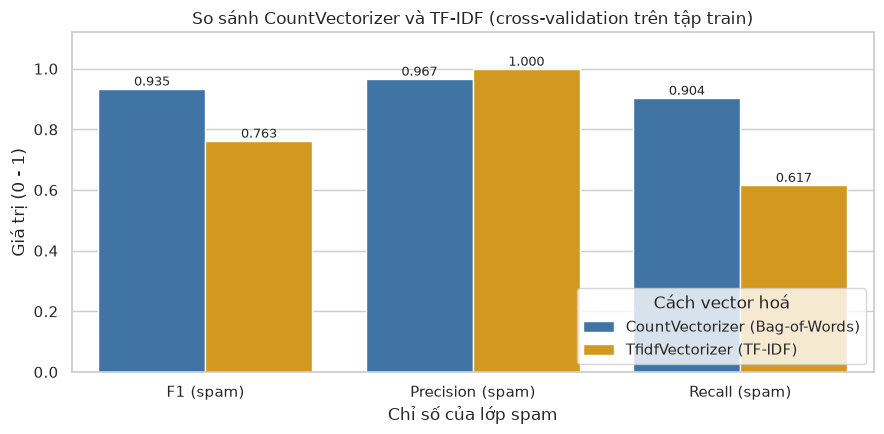

In [14]:
# B6 — So sánh CountVectorizer và TF-IDF
vec_rows = []
for ten, vectorizer in [("CountVectorizer (Bag-of-Words)", CountVectorizer()),
                        ("TfidfVectorizer (TF-IDF)", TfidfVectorizer())]:
    pipe = Pipeline([("vect", vectorizer), ("nb", MultinomialNB())])
    f1 = cross_val_score(pipe, X_train, y_train, cv=cv5, scoring="f1", n_jobs=-1)
    rc = cross_val_score(pipe, X_train, y_train, cv=cv5, scoring="recall", n_jobs=-1)
    pr = cross_val_score(pipe, X_train, y_train, cv=cv5, scoring="precision", n_jobs=-1)
    vec_rows.append({"Cách vector hoá": ten, "F1 (spam)": f1.mean(),
                     "Precision (spam)": pr.mean(), "Recall (spam)": rc.mean()})

vec_compare = pd.DataFrame(vec_rows)
print(vec_compare.to_string(index=False))

plot_df = vec_compare.melt(id_vars="Cách vector hoá", var_name="Chỉ số", value_name="Giá trị")
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=plot_df, x="Chỉ số", y="Giá trị", hue="Cách vector hoá",
            palette=["#2E75B6", "#F0A202"], ax=ax)
ax.set_title("So sánh CountVectorizer và TF-IDF (cross-validation trên tập train)")
ax.set_xlabel("Chỉ số của lớp spam")
ax.set_ylabel("Giá trị (0 - 1)")
ax.set_ylim(0, 1.12)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9)
ax.legend(title="Cách vector hoá", loc="lower right")
plt.tight_layout()
plt.show()

### Kết quả: Bag-of-Words thắng

- Count **F1 0,9345**; TF-IDF **0,7626** — precision 1,0000 nhưng recall chỉ **0,6170**, bỏ lọt gần 40% spam.
- IDF hạ trọng số từ xuất hiện nhiều, nhưng ở đây *free, win, call, claim* mới chính là tín hiệu spam mạnh nhất
  → mô hình rụt rè, recall sụp.
- Multinomial NB được thiết kế cho **số đếm nguyên**, không phải số thực đã chuẩn hoá L2.

→ Dùng `CountVectorizer` cho Bước 7.

## Bước 7. Pipeline + GridSearchCV

**Vì sao bắt buộc dùng Pipeline? — chống rò rỉ dữ liệu**

```python
# SAI: từ vựng được xây từ cả 5 fold, trong đó có phần sẽ dùng làm validation
X_train_vec = vectorizer.fit_transform(X_train)
grid.fit(X_train_vec, y_train)

# ĐÚNG: gói vào Pipeline, đưa text thô vào
pipeline = Pipeline([("vect", CountVectorizer()), ("nb", MultinomialNB())])
grid.fit(X_train, y_train)
```

Với Pipeline, mỗi fold chỉ `fit` vectorizer trên 4/5 dữ liệu, fold validation chỉ được `transform` — đúng như
tình huống gặp tin nhắn mới ngoài thực tế. Làm sai thì không báo lỗi, chỉ khiến điểm CV đẹp giả tạo.

**Lợi ích thứ hai:** tinh chỉnh được cả `ngram_range` (bắt cụm "call now", "free entry") và `min_df`, chứ không
chỉ mỗi `alpha`.

**`alpha` (Laplace smoothing):** NB nhân xác suất các từ với nhau; gặp một từ chưa từng thấy, xác suất 0 sẽ kéo
cả tích về 0. `alpha` cộng thêm một lượng nhỏ vào mọi số đếm. Lớn = mượt, thận trọng; nhỏ = nhạy, dễ overfit.

**`scoring='f1'` chứ không phải `'accuracy'`:** chấm bằng accuracy thì grid sẽ ưu ái cấu hình "chơi an toàn",
vì đoán ham đã đúng ~87%. `f1` mặc định tính cho lớp dương (spam).

In [15]:
# B7.1 — Pipeline + GridSearchCV (truyền text thô để tránh rò rỉ dữ liệu)
pipeline = Pipeline([
    ("vect", CountVectorizer(stop_words="english")),
    ("nb", MultinomialNB()),
])

param_grid = {
    "vect__ngram_range": [(1, 1), (1, 2)],
    "vect__min_df": [1, 2],
    "nb__alpha": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv5,
    scoring="f1",       # F1 của lớp spam, KHÔNG dùng accuracy
    n_jobs=-1,
    return_train_score=True,
    verbose=0,
)

grid.fit(X_train, y_train)

print("Tham số tốt nhất tìm được:")
for k, v in grid.best_params_.items():
    print(f"  - {k:>20}: {v}")
print(f"\nĐiểm F1 cross-validation tốt nhất: {grid.best_score_:.4f}")

Tham số tốt nhất tìm được:
  -            nb__alpha: 1.0
  -         vect__min_df: 1
  -    vect__ngram_range: (1, 2)

Điểm F1 cross-validation tốt nhất: 0.9434


In [16]:
# B7.2 — Top 5 tổ hợp tham số tốt nhất
results = pd.DataFrame(grid.cv_results_)
top5 = (results
        .sort_values("rank_test_score")
        .head(5)[["param_vect__ngram_range", "param_vect__min_df", "param_nb__alpha",
                  "mean_test_score", "std_test_score", "mean_train_score"]]
        .rename(columns={
            "param_vect__ngram_range": "ngram_range",
            "param_vect__min_df": "min_df",
            "param_nb__alpha": "alpha",
            "mean_test_score": "F1 CV (trung bình)",
            "std_test_score": "Độ lệch chuẩn",
            "mean_train_score": "F1 trên train",
        }))

print("TOP 5 TỔ HỢP THAM SỐ TỐT NHẤT")
print("=" * 95)
print(top5.to_string(index=False))

best_model = grid.best_estimator_
print("\nSố đặc trưng (từ/cụm từ) trong từ vựng cuối cùng:",
      f"{len(best_model.named_steps['vect'].vocabulary_):,}")

TOP 5 TỔ HỢP THAM SỐ TỐT NHẤT
ngram_range  min_df  alpha  F1 CV (trung bình)  Độ lệch chuẩn  F1 trên train
     (1, 2)       1 1.0000              0.9434         0.0164         0.9952
     (1, 2)       1 0.1000              0.9401         0.0127         0.9945
     (1, 2)       1 0.5000              0.9394         0.0206         0.9933
     (1, 2)       1 0.0500              0.9356         0.0154         0.9948
     (1, 2)       1 2.0000              0.9354         0.0087         0.9933

Số đặc trưng (từ/cụm từ) trong từ vựng cuối cùng: 30,960


### Toàn cảnh 24 tổ hợp

Heatmap và biểu đồ đường cho biết tham số nào thực sự quan trọng, và vùng tham số tốt có rộng không.

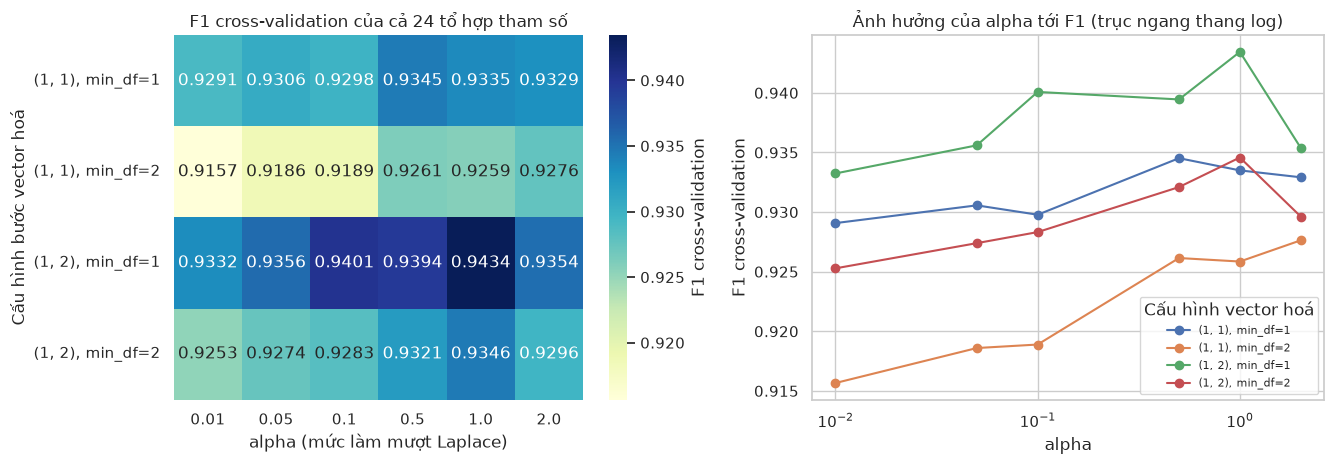

In [17]:
# B7.3 — Biểu đồ: toàn bộ 24 tổ hợp tham số
results["cau_hinh_vect"] = (results["param_vect__ngram_range"].astype(str)
                            + ", min_df=" + results["param_vect__min_df"].astype(str))
heat = results.pivot_table(index="cau_hinh_vect", columns="param_nb__alpha", values="mean_test_score")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

sns.heatmap(heat, annot=True, fmt=".4f", cmap="YlGnBu", ax=axes[0],
            cbar_kws={"label": "F1 cross-validation"})
axes[0].set_title("F1 cross-validation của cả 24 tổ hợp tham số")
axes[0].set_xlabel("alpha (mức làm mượt Laplace)")
axes[0].set_ylabel("Cấu hình bước vector hoá")

for ten_ch, nhom in results.groupby("cau_hinh_vect"):
    nhom = nhom.sort_values("param_nb__alpha")
    axes[1].plot(nhom["param_nb__alpha"], nhom["mean_test_score"], marker="o", label=ten_ch)
axes[1].set_xscale("log")
axes[1].set_title("Ảnh hưởng của alpha tới F1 (trục ngang thang log)")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("F1 cross-validation")
axes[1].legend(fontsize=8, title="Cấu hình vector hoá")

plt.tight_layout()
plt.show()

### Nhận xét Bước 7

- Tốt nhất: **`ngram_range=(1,2)`, `min_df=1`, `alpha=1.0`** → **F1 CV 0,9434** (cấu hình mặc định ở Bước 6: 0,9345).
- Cả 5 tổ hợp đầu đều `(1,2)` + `min_df=1`: bigram giúp ích, còn loại bỏ từ hiếm thì có hại — nhiều "từ hiếm"
  chính là số tổng đài chỉ xuất hiện một lần nhưng rất đặc trưng cho spam.
- Heatmap cho thấy hàng `min_df=2` nhạt hơn ở **mọi** giá trị alpha → `min_df` quan trọng hơn `alpha`.
- F1 train ~0,995 so với CV ~0,943: bình thường với từ vựng 30.960 đặc trưng, chưa phải overfit nghiêm trọng.

## Bước 8. Đánh giá trên tập test

Mọi quyết định đã chốt ở Bước 7 bằng cross-validation, nên đây là lần duy nhất dùng tập test.

In [18]:
# B8.1 — Báo cáo phân loại trên tập test
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("BÁO CÁO PHÂN LOẠI TRÊN TẬP TEST")
print("=" * 70)
print(classification_report(y_test, y_pred, target_names=["ham (0)", "spam (1)"], digits=4))

print("CHỈ SỐ RIÊNG CHO LỚP SPAM (lớp ta thực sự quan tâm)")
print("-" * 70)
print(f"  Accuracy (toàn bộ) : {accuracy_score(y_test, y_pred):.4f}  <- chỉ để tham khảo, KHÔNG phải chỉ số chính")
print(f"  Precision (spam)   : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall    (spam)   : {recall_score(y_test, y_pred):.4f}")
print(f"  F1-score  (spam)   : {f1_score(y_test, y_pred):.4f}")

BÁO CÁO PHÂN LOẠI TRÊN TẬP TEST
              precision    recall  f1-score   support

     ham (0)     0.9869    0.9978    0.9923       903
    spam (1)     0.9835    0.9084    0.9444       131

    accuracy                         0.9865      1034
   macro avg     0.9852    0.9531    0.9684      1034
weighted avg     0.9864    0.9865    0.9862      1034

CHỈ SỐ RIÊNG CHO LỚP SPAM (lớp ta thực sự quan tâm)
----------------------------------------------------------------------
  Accuracy (toàn bộ) : 0.9865  <- chỉ để tham khảo, KHÔNG phải chỉ số chính
  Precision (spam)   : 0.9835
  Recall    (spam)   : 0.9084
  F1-score  (spam)   : 0.9444


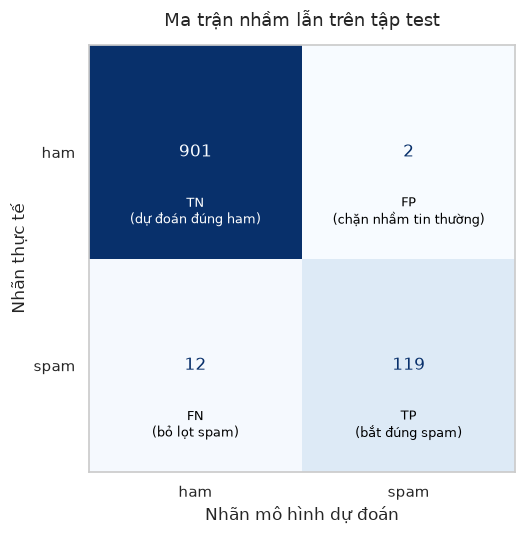

Ý NGHĨA NGHIỆP VỤ CỦA TỪNG Ô
  True Negative  (TN) =  901  | Tin thường được nhận đúng là tin thường -> mọi thứ ổn.
  False Positive (FP) =    2  | Tin THƯỜNG bị chặn nhầm thành spam.
                              | => NGHIÊM TRỌNG NHẤT: người dùng có thể mất mã OTP,
                              |    tin nhắn của người thân, lịch hẹn quan trọng.
  False Negative (FN) =   12  | Tin SPAM lọt vào hộp thư chính.
                              | => Gây khó chịu, nhưng người dùng chỉ cần xoá đi là xong.
  True Positive  (TP) =  119  | Bắt đúng spam -> đúng mục tiêu của bộ lọc.


In [19]:
# B8.2 — Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()   # thứ tự của sklearn: TN, FP, FN, TP

fig, ax = plt.subplots(figsize=(6.5, 5.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Ma trận nhầm lẫn trên tập test", fontsize=13, pad=14)
ax.set_xlabel("Nhãn mô hình dự đoán")
ax.set_ylabel("Nhãn thực tế")
ax.grid(False)

chu_thich = [["TN\n(dự đoán đúng ham)", "FP\n(chặn nhầm tin thường)"],
             ["FN\n(bỏ lọt spam)",      "TP\n(bắt đúng spam)"]]
for i in range(2):
    for j in range(2):
        mau_chu = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i + 0.28, chu_thich[i][j], ha="center", va="center",
                fontsize=9, color=mau_chu)
plt.tight_layout()
plt.show()

print("Ý NGHĨA NGHIỆP VỤ CỦA TỪNG Ô")
print("=" * 78)
print(f"  True Negative  (TN) = {tn:>4}  | Tin thường được nhận đúng là tin thường -> mọi thứ ổn.")
print(f"  False Positive (FP) = {fp:>4}  | Tin THƯỜNG bị chặn nhầm thành spam.")
print(f"                              | => NGHIÊM TRỌNG NHẤT: người dùng có thể mất mã OTP,")
print(f"                              |    tin nhắn của người thân, lịch hẹn quan trọng.")
print(f"  False Negative (FN) = {fn:>4}  | Tin SPAM lọt vào hộp thư chính.")
print(f"                              | => Gây khó chịu, nhưng người dùng chỉ cần xoá đi là xong.")
print(f"  True Positive  (TP) = {tp:>4}  | Bắt đúng spam -> đúng mục tiêu của bộ lọc.")

### Ý nghĩa các con số

Tập test: 1.034 tin (131 spam, 903 ham).

- **Precision 0,9835** — trong số tin bị gắn nhãn spam, 98,35% đúng là spam.
- **Recall 0,9084** — bắt được 119/131 tin spam, bỏ lọt 12.
- **F1 0,9444** — trung bình điều hoà, phạt nặng sự mất cân đối (precision 100% + recall 10% chỉ cho F1 ~0,18).
- **FP = 2** trên 903 tin ham (0,22%) — đúng ưu tiên đặt ra ở Bước 1.
- Accuracy 0,9865 chỉ để tham khảo; Bước 9 sẽ cho thấy vì sao.

### PR curve và ROC curve

Xem hiệu năng trên toàn dải ngưỡng, thay vì chỉ tại một điểm 0,5.

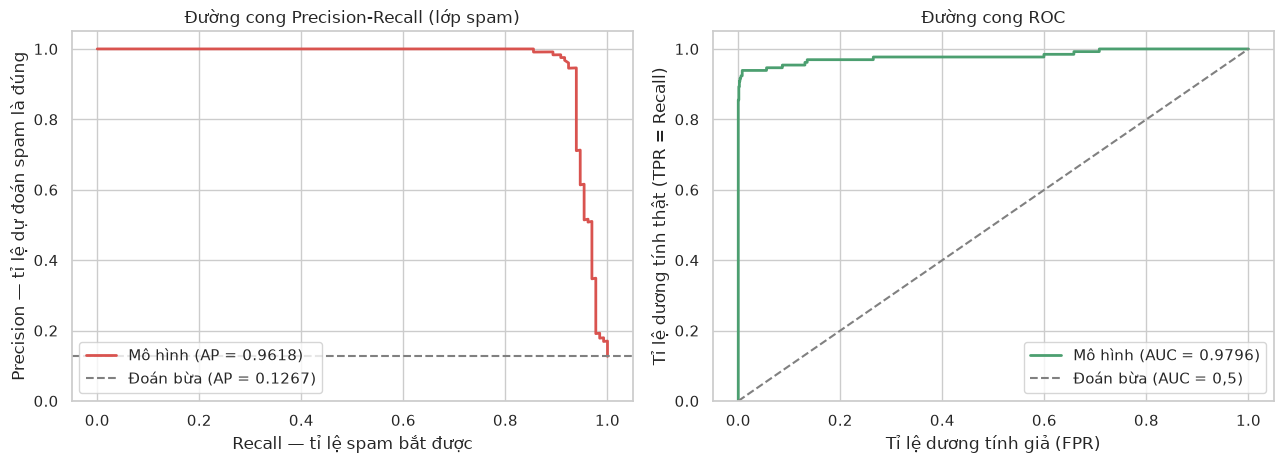

Average Precision (AP, diện tích dưới đường PR): 0.9618
ROC-AUC                                        : 0.9796
Đường tham chiếu của PR curve (tỉ lệ spam trong test): 0.1267


In [20]:
# B8.3 — Đường cong Precision-Recall và ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
axes[0].plot(recall, precision, color="#D9534F", lw=2, label=f"Mô hình (AP = {ap:.4f})")
baseline_pr = y_test.mean()
axes[0].axhline(baseline_pr, ls="--", color="gray",
                label=f"Đoán bừa (AP = {baseline_pr:.4f})")
axes[0].set_title("Đường cong Precision-Recall (lớp spam)")
axes[0].set_xlabel("Recall — tỉ lệ spam bắt được")
axes[0].set_ylabel("Precision — tỉ lệ dự đoán spam là đúng")
axes[0].set_ylim(0, 1.05); axes[0].legend(loc="lower left")

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#4C9F70", lw=2, label=f"Mô hình (AUC = {auc:.4f})")
axes[1].plot([0, 1], [0, 1], ls="--", color="gray", label="Đoán bừa (AUC = 0,5)")
axes[1].set_title("Đường cong ROC")
axes[1].set_xlabel("Tỉ lệ dương tính giả (FPR)")
axes[1].set_ylabel("Tỉ lệ dương tính thật (TPR = Recall)")
axes[1].set_ylim(0, 1.05); axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"Average Precision (AP, diện tích dưới đường PR): {ap:.4f}")
print(f"ROC-AUC                                        : {auc:.4f}")
print(f"Đường tham chiếu của PR curve (tỉ lệ spam trong test): {baseline_pr:.4f}")

### Vì sao PR curve đáng tin hơn ROC-AUC ở đây?

- FPR = FP/(FP+TN), mẫu số là **toàn bộ lớp âm** (903 tin ham). Chặn nhầm 30 tin cũng chỉ làm FPR ≈ 0,033 —
  lớp âm đông đảo "pha loãng" sai lầm, ROC-AUC bị thổi phồng.
- Precision = TP/(TP+FP), **không có TN** trong công thức → mỗi lần chặn nhầm là precision tụt thấy rõ.
- Kết quả: ROC-AUC **0,9796**, AP **0,9618**. Nhưng mốc đoán bừa của ROC là 0,5, còn của AP chỉ **0,1267**
  (đúng bằng tỉ lệ spam) — nên AP mang nhiều thông tin hơn.

Quy tắc: quan tâm lớp hiếm → dùng PR/AP. Hai lớp quan trọng ngang nhau → ROC-AUC.

### Kiểm tra độ ổn định

Kết quả test chỉ là một lần chia. Cross-validation cho biết mô hình ổn định đến đâu.
Phải truyền **cả pipeline + text thô**, nếu không lại rò rỉ dữ liệu như đã nói ở Bước 7.

In [21]:
# B8.4 — Cross-validation kiểm tra độ ổn định
cv_f1 = cross_val_score(clone(best_model), X_train, y_train, cv=cv5, scoring="f1", n_jobs=-1)
cv_pr = cross_val_score(clone(best_model), X_train, y_train, cv=cv5, scoring="precision", n_jobs=-1)
cv_rc = cross_val_score(clone(best_model), X_train, y_train, cv=cv5, scoring="recall", n_jobs=-1)

print("CROSS-VALIDATION 5-FOLD TRÊN TẬP TRAIN (chỉ số của lớp spam)")
print("=" * 70)
print(f"  F1        : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}   | từng fold: {np.round(cv_f1, 4)}")
print(f"  Precision : {cv_pr.mean():.4f} ± {cv_pr.std():.4f}")
print(f"  Recall    : {cv_rc.mean():.4f} ± {cv_rc.std():.4f}")
print(f"\nĐể so sánh — F1 trên tập test (chưa từng dùng): {f1_score(y_test, y_pred):.4f}")

CROSS-VALIDATION 5-FOLD TRÊN TẬP TRAIN (chỉ số của lớp spam)
  F1        : 0.9434 ± 0.0164   | từng fold: [0.9246 0.94   0.951  0.9709 0.9307]
  Precision : 0.9754 ± 0.0083
  Recall    : 0.9138 ± 0.0251

Để so sánh — F1 trên tập test (chưa từng dùng): 0.9444


**F1 CV = 0,9434 ± 0,0164** (5 fold: 0,9246 – 0,9709) — rất đồng đều, không fold nào bất thường.

F1 test **0,9444** gần như trùng trung bình CV → kết quả không phải may mắn.

Precision CV (0,9754) > recall CV (0,9138): mô hình nhất quán thiên về "thà bỏ sót còn hơn chặn nhầm".

### Phân tích ngưỡng

`predict()` ngầm dùng ngưỡng 0,5. Đổi ngưỡng chính là núm vặn đánh đổi precision ↔ recall, không cần huấn luyện lại.

In [22]:
# B8.5 — Bảng so sánh các ngưỡng quyết định
rows = []
for nguong in [0.3, 0.5, 0.7, 0.9]:
    y_pred_t = (y_proba >= nguong).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()
    rows.append({
        "Ngưỡng": nguong,
        "Precision (spam)": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall (spam)": recall_score(y_test, y_pred_t),
        "F1 (spam)": f1_score(y_test, y_pred_t),
        "FP (chặn nhầm)": fp_t,
        "FN (bỏ lọt)": fn_t,
    })

threshold_table = pd.DataFrame(rows)
print("ẢNH HƯỞNG CỦA NGƯỠNG QUYẾT ĐỊNH TỚI PRECISION / RECALL")
print("=" * 90)
print(threshold_table.to_string(index=False))

ẢNH HƯỞNG CỦA NGƯỠNG QUYẾT ĐỊNH TỚI PRECISION / RECALL
 Ngưỡng  Precision (spam)  Recall (spam)  F1 (spam)  FP (chặn nhầm)  FN (bỏ lọt)
 0.3000            0.9453         0.9237     0.9344               7           10
 0.5000            0.9835         0.9084     0.9444               2           12
 0.7000            0.9915         0.8931     0.9398               1           14
 0.9000            0.9914         0.8779     0.9312               1           16


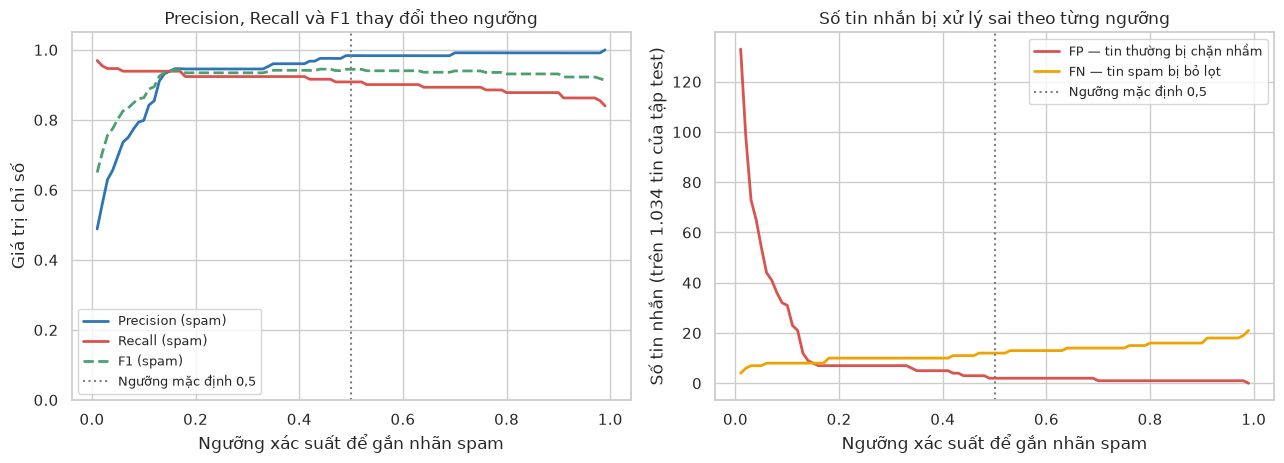

In [23]:
# B8.6 — Biểu đồ: chỉ số và số tin sai theo ngưỡng
luoi_nguong = np.linspace(0.01, 0.99, 99)
pr_list, rc_list, f1_list, fp_list = [], [], [], []
for t in luoi_nguong:
    yp = (y_proba >= t).astype(int)
    pr_list.append(precision_score(y_test, yp, zero_division=1))
    rc_list.append(recall_score(y_test, yp))
    f1_list.append(f1_score(y_test, yp))
    fp_list.append(confusion_matrix(y_test, yp).ravel()[1])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(luoi_nguong, pr_list, label="Precision (spam)", color="#2E75B6", lw=2)
axes[0].plot(luoi_nguong, rc_list, label="Recall (spam)", color="#D9534F", lw=2)
axes[0].plot(luoi_nguong, f1_list, label="F1 (spam)", color="#4C9F70", lw=2, ls="--")
axes[0].axvline(0.5, color="gray", ls=":", label="Ngưỡng mặc định 0,5")
axes[0].set_title("Precision, Recall và F1 thay đổi theo ngưỡng")
axes[0].set_xlabel("Ngưỡng xác suất để gắn nhãn spam")
axes[0].set_ylabel("Giá trị chỉ số")
axes[0].set_ylim(0, 1.05); axes[0].legend(loc="lower left", fontsize=9)

fn_list = [131 - round(r * 131) for r in rc_list]
axes[1].plot(luoi_nguong, fp_list, label="FP — tin thường bị chặn nhầm", color="#D9534F", lw=2)
axes[1].plot(luoi_nguong, fn_list, label="FN — tin spam bị bỏ lọt", color="#F0A202", lw=2)
axes[1].axvline(0.5, color="gray", ls=":", label="Ngưỡng mặc định 0,5")
axes[1].set_title("Số tin nhắn bị xử lý sai theo từng ngưỡng")
axes[1].set_xlabel("Ngưỡng xác suất để gắn nhãn spam")
axes[1].set_ylabel("Số tin nhắn (trên 1.034 tin của tập test)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Metric quyết định

**Không phải accuracy** — đoán ham suông đã đúng ~87% (Bước 9 chứng minh bằng số).

**Là precision của lớp spam**, kèm ràng buộc recall không quá thấp: chặn nhầm một mã OTP thì không khôi phục
được, còn spam lọt vào thì xoá là xong.

| Ngưỡng | Precision | Recall | F1 | FP | FN |
|---|---|---|---|---|---|
| 0,3 | 0,9453 | **0,9237** | 0,9344 | 7 | 10 |
| **0,5** | 0,9835 | 0,9084 | **0,9444** | 2 | 12 |
| 0,7 | **0,9915** | 0,8931 | 0,9398 | **1** | 14 |
| 0,9 | 0,9914 | 0,8779 | 0,9312 | **1** | 16 |

- Hạ xuống 0,3: bắt thêm 2 spam nhưng chặn nhầm tăng 2 → 7. Lỗ.
- Nâng lên 0,7: chỉ còn 1 tin ham bị chặn oan, đổi lại lọt thêm 2 spam.
- Từ 0,7 lên 0,9 không được gì thêm: NB cho xác suất dồn về hai cực nên gần như không có mẫu ở vùng giữa —
  biểu đồ quét mịn cho thấy dải 0,2–0,99 gần như phẳng.

**Khuyến nghị:** spam vào thư mục riêng xem lại được → giữ 0,5. Xoá thẳng → nâng 0,7.

## Bước 9. Mất cân bằng dữ liệu

Có cần cân bằng lại không? Đo bằng thực nghiệm, so sánh 4 cấu hình:

| Cấu hình | Cách làm |
|---|---|
| Dummy | `DummyClassifier(strategy='most_frequent')` — luôn đoán ham |
| Naive Bayes gốc | Giữ nguyên dữ liệu mất cân bằng |
| NB + oversampling | Nhân bản mẫu spam cho bằng ham, **chỉ trên tập train** |
| NB + sample_weight | Không đụng dữ liệu, chỉ tăng trọng số mẫu spam |

In [24]:
# B9.1 — So sánh 4 cấu hình xử lý mất cân bằng
def danh_gia(model, ten):
    """Trả về các chỉ số của một cấu hình trên tập test."""
    yp = model.predict(X_test)
    tn_i, fp_i, fn_i, tp_i = confusion_matrix(y_test, yp).ravel()
    return {
        "Cấu hình": ten,
        "Accuracy": accuracy_score(y_test, yp),
        "Precision (spam)": precision_score(y_test, yp, zero_division=0),
        "Recall (spam)": recall_score(y_test, yp, zero_division=0),
        "F1 (spam)": f1_score(y_test, yp, zero_division=0),
        "FP (chặn nhầm)": fp_i,
        "FN (bỏ lọt)": fn_i,
    }

ket_qua = []

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
ket_qua.append(danh_gia(dummy, "Dummy (luôn đoán ham)"))

ket_qua.append(danh_gia(best_model, "Naive Bayes gốc"))

# Oversampling: chỉ làm trên tập train, nếu không bản sao sẽ lọt sang test
train_df = pd.DataFrame({"text": X_train.values, "y": y_train.values})
spam_df = train_df[train_df["y"] == 1]
ham_df = train_df[train_df["y"] == 0]
spam_upsampled = spam_df.sample(n=len(ham_df), replace=True, random_state=RANDOM_STATE)
train_bal = pd.concat([ham_df, spam_upsampled]).sample(frac=1, random_state=RANDOM_STATE)

print(f"Tập train gốc           : {len(train_df):,} mẫu ({train_df['y'].mean()*100:.1f}% spam)")
print(f"Tập train sau oversample: {len(train_bal):,} mẫu ({train_bal['y'].mean()*100:.1f}% spam)")

model_over = clone(best_model)
model_over.fit(train_bal["text"], train_bal["y"])
ket_qua.append(danh_gia(model_over, "NB + Oversampling"))

w = (y_train == 0).sum() / (y_train == 1).sum()
sample_weight = np.where(y_train == 1, w, 1.0)
model_w = clone(best_model)
model_w.fit(X_train, y_train, nb__sample_weight=sample_weight)
ket_qua.append(danh_gia(model_w, f"NB + sample_weight (w={w:.1f})"))

bang_so_sanh = pd.DataFrame(ket_qua)
print("\nSO SÁNH 4 CẤU HÌNH TRÊN CÙNG TẬP TEST")
print("=" * 92)
print(bang_so_sanh.to_string(index=False))

Tập train gốc           : 4,135 mẫu (12.6% spam)
Tập train sau oversample: 7,226 mẫu (50.0% spam)



SO SÁNH 4 CẤU HÌNH TRÊN CÙNG TẬP TEST
                  Cấu hình  Accuracy  Precision (spam)  Recall (spam)  F1 (spam)  FP (chặn nhầm)  FN (bỏ lọt)
     Dummy (luôn đoán ham)    0.8733            0.0000         0.0000     0.0000               0          131
           Naive Bayes gốc    0.9865            0.9835         0.9084     0.9444               2           12
         NB + Oversampling    0.9681            0.8182         0.9618     0.8842              28            5
NB + sample_weight (w=6.9)    0.9613            0.7791         0.9695     0.8639              36            4


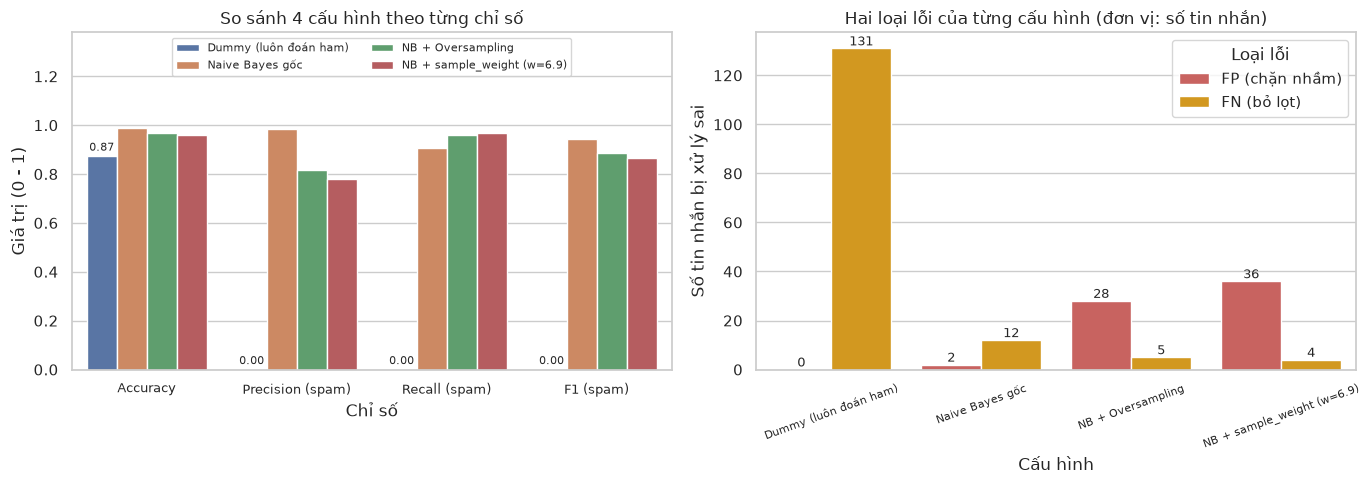

In [25]:
# B9.2 — Biểu đồ so sánh 4 cấu hình
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_cfg = bang_so_sanh.melt(id_vars="Cấu hình",
                             value_vars=["Accuracy", "Precision (spam)", "Recall (spam)", "F1 (spam)"],
                             var_name="Chỉ số", value_name="Giá trị")
sns.barplot(data=plot_cfg, x="Chỉ số", y="Giá trị", hue="Cấu hình", ax=axes[0])
axes[0].set_title("So sánh 4 cấu hình theo từng chỉ số")
axes[0].set_xlabel("Chỉ số")
axes[0].set_ylabel("Giá trị (0 - 1)")
axes[0].set_ylim(0, 1.38)
axes[0].tick_params(axis="x", labelsize=9)
axes[0].legend(fontsize=8, ncol=2, loc="upper center")
axes[0].bar_label(axes[0].containers[0], fmt="%.2f", fontsize=8, padding=2)

plot_err = bang_so_sanh.melt(id_vars="Cấu hình", value_vars=["FP (chặn nhầm)", "FN (bỏ lọt)"],
                             var_name="Loại lỗi", value_name="Số tin nhắn")
sns.barplot(data=plot_err, x="Cấu hình", y="Số tin nhắn", hue="Loại lỗi",
            palette={"FP (chặn nhầm)": "#D9534F", "FN (bỏ lọt)": "#F0A202"}, ax=axes[1])
axes[1].set_title("Hai loại lỗi của từng cấu hình (đơn vị: số tin nhắn)")
axes[1].set_xlabel("Cấu hình")
axes[1].set_ylabel("Số tin nhắn bị xử lý sai")
axes[1].tick_params(axis="x", rotation=20, labelsize=8)
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=9)

plt.tight_layout()
plt.show()

### Kết luận Bước 9

**1. Dummy đạt 87,33% accuracy nhưng vô dụng hoàn toàn.**

Nó luôn trả lời "ham" nên đúng 87,33% số lần, nhưng Precision = Recall = F1 = **0** và để lọt cả 131 tin spam.
Nếu chỉ báo cáo accuracy, một mô hình như vậy vẫn có thể được trình bày là "gần 90% độ chính xác".
Khoảng cách thật nằm ở F1: **0,9444 so với 0,0000**.

**2. Có cần cân bằng dữ liệu không? — KHÔNG.**

| Cấu hình | Precision | Recall | F1 | FP | FN |
|---|---|---|---|---|---|
| Naive Bayes gốc | **0,9835** | 0,9084 | **0,9444** | **2** | 12 |
| NB + Oversampling | 0,8182 | 0,9618 | 0,8842 | 28 | 5 |
| NB + sample_weight | 0,7791 | **0,9695** | 0,8639 | 36 | 4 |

Recall tăng thật (bắt thêm 7–8 spam) nhưng **tin ham bị chặn nhầm tăng từ 2 lên 28 và 36** — lỗ nặng theo thang
giá trị ở Bước 1. Nguyên nhân: cân bằng dữ liệu làm méo **prior**, khiến mô hình tưởng spam và ham xuất hiện
ngang nhau trong khi thực tế spam chỉ ~12,6%.

Hai cách cho kết quả gần nhau nhưng không trùng khớp, vì oversampling lấy mẫu *có hoàn lại* nên mỗi tin spam
không được nhân đúng *w* lần.

→ Giữ nguyên dữ liệu mất cân bằng. Naive Bayes vốn đã xử lý tốt việc này qua prior.

## Bước 10. Giải thích mô hình

Thế mạnh của Naive Bayes: mở ra xem được nó dựa vào từ nào để quyết định.

`feature_log_prob_[c][i]` là log xác suất gặp từ *i* trong lớp *c*; hiệu hai dòng cho biết từ đó nghiêng về lớp nào.

In [26]:
# B10.1 — Top 20 từ đặc trưng cho mỗi lớp
vect = best_model.named_steps["vect"]
nb = best_model.named_steps["nb"]

feature_names = np.array(vect.get_feature_names_out())
log_prob_ham, log_prob_spam = nb.feature_log_prob_[0], nb.feature_log_prob_[1]

log_odds = log_prob_spam - log_prob_ham

top_spam_idx = np.argsort(log_odds)[::-1][:20]
top_ham_idx = np.argsort(log_odds)[:20]

bang_tu = pd.DataFrame({
    "Hạng": range(1, 21),
    "Từ/cụm từ đặc trưng SPAM": feature_names[top_spam_idx],
    "Log-odds (spam)": log_odds[top_spam_idx],
    "Từ/cụm từ đặc trưng HAM": feature_names[top_ham_idx],
    "Log-odds (ham)": log_odds[top_ham_idx],
})
print("TOP 20 TỪ ĐẶC TRƯNG CHO MỖI LỚP")
print("=" * 92)
print(bang_tu.to_string(index=False))

TOP 20 TỪ ĐẶC TRƯNG CHO MỖI LỚP
 Hạng Từ/cụm từ đặc trưng SPAM  Log-odds (spam) Từ/cụm từ đặc trưng HAM  Log-odds (ham)
    1                    claim           4.7879                      gt         -4.9052
    2                    prize           4.6871                      lt         -4.9007
    3                     150p           4.2816                   lt gt         -4.7858
    4                    nokia           4.2351                     lor         -4.4078
    5                     tone           4.1084                      da         -4.2475
    6                      www           4.0670                      ì_         -4.0669
    7                       18           4.0528                   later         -3.8066
    8                       16           4.0238                   doing         -3.7792
    9                      500           3.9632                    said         -3.7510
   10               guaranteed           3.9632                  really         -3.7072


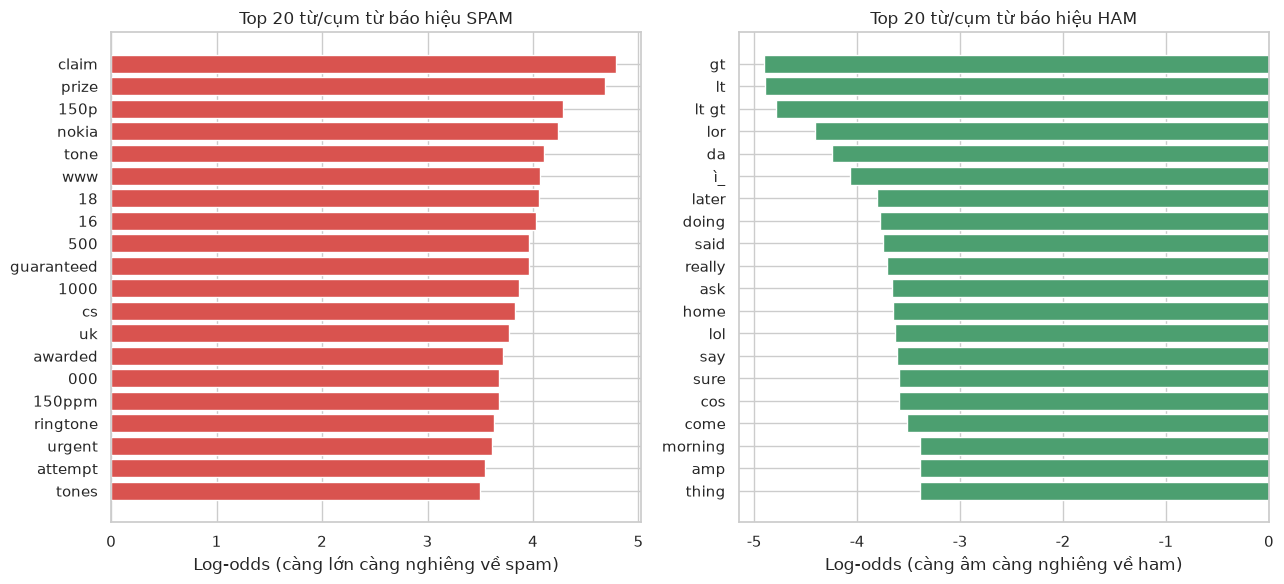

In [27]:
# B10.2 — Biểu đồ log-odds của các từ
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].barh(range(20), log_odds[top_spam_idx][::-1], color="#D9534F")
axes[0].set_yticks(range(20)); axes[0].set_yticklabels(feature_names[top_spam_idx][::-1])
axes[0].set_title("Top 20 từ/cụm từ báo hiệu SPAM")
axes[0].set_xlabel("Log-odds (càng lớn càng nghiêng về spam)")

axes[1].barh(range(20), log_odds[top_ham_idx][::-1], color="#4C9F70")
axes[1].set_yticks(range(20)); axes[1].set_yticklabels(feature_names[top_ham_idx][::-1])
axes[1].set_title("Top 20 từ/cụm từ báo hiệu HAM")
axes[1].set_xlabel("Log-odds (càng âm càng nghiêng về ham)")

plt.tight_layout()
plt.show()

### Nhận xét Bước 10

- Phía spam: *claim, prize, nokia, tone, guaranteed, awarded, urgent, ringtone*, cùng *150p, 150ppm, cs, 1000* —
  đúng từ vựng tin trúng thưởng / tải nhạc chuông.
- Phía ham: *later, doing, home, morning, really, come*, tiếng lóng *lor, da, lol*, và *gt, lt, lt gt* —
  chính là `&gt;` / `&lt;` chưa giải mã. Mô hình đang học một dấu vết kỹ thuật, không phải ngôn ngữ thật;
  trên dữ liệu mới tín hiệu này sẽ biến mất.
- Top 20 gần như toàn từ đơn dù mô hình có 30.960 đặc trưng gồm cả bigram: bigram vẫn giúp F1 tăng, nhưng đóng
  góp trải đều trên nhiều cụm chứ không tập trung thành vài tín hiệu cực mạnh.

## Bước 11. Triển khai

Lưu **cả pipeline** vào một file thay vì tách vectorizer và model: nạp lên là dùng ngay với text thô, không thể
quên bước nào, không thể ghép nhầm phiên bản vectorizer (loại bug chạy không báo lỗi nhưng trả kết quả sai).

In [28]:
# B11.1 — Lưu mô hình và nạp lại kiểm chứng
MODEL_PATH = "spam_model.pkl"

joblib.dump(best_model, MODEL_PATH)
print(f"Đã lưu mô hình vào '{MODEL_PATH}' ({os.path.getsize(MODEL_PATH) / 1024:.1f} KB)")

loaded_model = joblib.load(MODEL_PATH)
print("Nạp lại thành công. Dự đoán của mô hình nạp lại có trùng khớp không?",
      np.array_equal(loaded_model.predict(X_test), y_pred))

Đã lưu mô hình vào 'spam_model.pkl' (1447.3 KB)
Nạp lại thành công. Dự đoán của mô hình nạp lại có trùng khớp không? True


In [29]:
# B11.2 — Hàm dự đoán và demo trên tin nhắn mới
def du_doan_spam(tin_nhan, model=None, nguong=0.5):
    """Nhận văn bản thô, trả về (nhãn, xác suất spam)."""
    if model is None:
        model = loaded_model
    xac_suat_spam = float(model.predict_proba([tin_nhan])[0, 1])
    nhan = "SPAM" if xac_suat_spam >= nguong else "HAM"
    return nhan, xac_suat_spam

tin_nhan_thu = [
    "Congratulations! You have WON a FREE iPhone 15. Click http://bit.ly/claim-now to claim your prize NOW!",
    "URGENT! Your mobile number has been awarded a 2000 pound cash prize. Call 09061701461 to claim. T&C apply.",
    "Hey, are we still meeting for lunch at 12? Let me know if you're running late.",
    "Mom said she'll pick up the kids today, so don't worry about leaving work early.",
]

print("KẾT QUẢ DỰ ĐOÁN TRÊN TIN NHẮN MỚI")
print("=" * 95)
for tn in tin_nhan_thu:
    nhan, prob = du_doan_spam(tn)
    danh_dau = "[X]" if nhan == "SPAM" else "[v]"
    print(f"{danh_dau} [{nhan:>4}] (xác suất spam = {prob:.4f})")
    print(f"    Nội dung: {tn[:86]}{'...' if len(tn) > 86 else ''}")
    print("-" * 95)

KẾT QUẢ DỰ ĐOÁN TRÊN TIN NHẮN MỚI
[X] [SPAM] (xác suất spam = 1.0000)
    Nội dung: Congratulations! You have WON a FREE iPhone 15. Click http://bit.ly/claim-now to claim...
-----------------------------------------------------------------------------------------------
[X] [SPAM] (xác suất spam = 1.0000)
    Nội dung: URGENT! Your mobile number has been awarded a 2000 pound cash prize. Call 09061701461 ...
-----------------------------------------------------------------------------------------------
[v] [ HAM] (xác suất spam = 0.0000)
    Nội dung: Hey, are we still meeting for lunch at 12? Let me know if you're running late.
-----------------------------------------------------------------------------------------------
[v] [ HAM] (xác suất spam = 0.0000)
    Nội dung: Mom said she'll pick up the kids today, so don't worry about leaving work early.
-----------------------------------------------------------------------------------------------


### Nhận xét Bước 11

Đúng cả 4 tin nhắn mới, xác suất rất dứt khoát: spam ~1,0000, ham ~0,0000 — đặc trưng của Naive Bayes do nhân
xác suất nhiều từ với nhau.

Vì vậy **không nên hiểu con số này là "độ chắc chắn" theo nghĩa thống kê**: nó xếp hạng tốt nhưng chưa được hiệu
chỉnh (*calibrated*). Cần xác suất có ý nghĩa thật thì bọc bằng `CalibratedClassifierCV`.

---

## Kết luận và hướng phát triển

Mô hình cuối: `CountVectorizer(stop_words='english', ngram_range=(1,2), min_df=1)` + `MultinomialNB(alpha=1.0)`,
gói trong một `Pipeline`.

| Chỉ số (lớp spam) | Test |
|---|---|
| Precision | **0,9835** |
| Recall | **0,9084** |
| F1-score | **0,9444** |
| AP / ROC-AUC | 0,9618 / 0,9796 |
| Accuracy (tham khảo) | 0,9865 |
| F1 cross-validation | **0,9434 ± 0,0164** |

Bắt đúng **119/131 spam**, chỉ **chặn nhầm 2/903** tin ham.

### Bài học

1. **Accuracy nói dối khi dữ liệu mất cân bằng** — Dummy 87,33% accuracy nhưng F1 = 0.
2. **Pipeline là để chống rò rỉ dữ liệu**, không phải để code gọn.
3. **Không bước tiền xử lý nào là bắt buộc** — làm sạch làm F1 giảm, cân bằng dữ liệu cũng làm F1 giảm.
4. **Chọn metric theo nghiệp vụ**: ở đây FP đắt hơn FN nên ưu tiên precision; sàng lọc ung thư thì ngược lại.

### Hạn chế của Naive Bayes

- Giả định các từ **độc lập** là sai với ngôn ngữ tự nhiên (có "call" thì khả năng có "now" cao hơn hẳn). Bigram
  chỉ giảm nhẹ chứ không giải quyết gốc rễ — nhưng để phân loại đúng chỉ cần xếp hạng đúng, không cần xác suất
  chính xác.
- Xác suất không được hiệu chỉnh, dồn về 0 hoặc 1.
- Bag-of-Words bỏ thứ tự từ; không hiểu từ đồng nghĩa, đổi từ hay viết sai chính tả (*"fr33"*) là né được.
- Chỉ dùng được cho SMS tiếng Anh.

### Hướng phát triển

1. So sánh với **Logistic Regression / Linear SVM** — không đặt giả định độc lập, thường hơn 1–3% F1, vẫn rất rẻ.
2. Thêm trigram, n-gram ký tự (`analyzer='char_wb'`) để bắt biến thể viết sai; thêm đặc trưng thủ công như độ
   dài, tỉ lệ chữ in hoa, số lượng chữ số.
3. Fine-tune BERT/DistilBERT nếu cần thêm vài phần trăm — đổi lại chi phí gấp hàng nghìn lần và mất khả năng
   giải thích.
4. `CalibratedClassifierCV` nếu cần hiển thị độ tin cậy cho người dùng.
5. Huấn luyện lại định kỳ: spam liên tục tiến hoá (*concept drift*), dữ liệu này có từ năm 2012.